# Load Data

In [2]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio 
import pdb #for adding breakpoints to code
from sklearn.model_selection import train_test_split


# Load Dataset into Memory


In [3]:
#code r'C:\Users\Usselman Lab\VNA_model'


In [4]:
# Specify the path to the root directory
root_directory = r'E:\GitRepo\rawdata'  # Change this to the actual path
# Use glob to get paths of all text files in the subdirectories
text_file_paths = glob.glob(os.path.join(root_directory, '*', '*.txt'))

# Print the list of file paths
#for file_path in text_file_paths:
    #print(file_path)

# Creates an empty list to store the X data in
X = []

# Creates an empty list to store the Y data in (Y data is just all of the different 15 samples)
Y = []

for file_path in text_file_paths:
    X.append(pd.read_csv(file_path, sep = '\t', skiprows = 16).drop(columns = ['PNT','FREQ1.GHZ','FREQ2.GHZ', 'LOGMAG2', 'FREQ3.GHZ', 'FREQ4.GHZ','LOGMAG3', 'LOGMAG4']).to_numpy())
    # Grab the folder name as a label for each array
    folder_name = os.path.basename(os.path.dirname(file_path))
    Y.append(folder_name)
print(X)
print ((hex(id(Y))))
print (id(Y))

[array([[-48.49731],
       [-53.73856],
       [-50.60245],
       ...,
       [-17.57865],
       [-17.4322 ],
       [-17.27229]]), array([[-48.68046],
       [-54.76069],
       [-51.38137],
       ...,
       [-17.49081],
       [-17.45769],
       [-17.35745]]), array([[-48.92503],
       [-56.70356],
       [-53.49392],
       ...,
       [-17.45165],
       [-17.35543],
       [-17.38622]]), array([[-48.6503 ],
       [-54.85603],
       [-51.28867],
       ...,
       [-17.48774],
       [-17.43703],
       [-17.42829]]), array([[-48.95243],
       [-54.6285 ],
       [-51.60266],
       ...,
       [-17.47794],
       [-17.48089],
       [-17.24839]]), array([[-48.4344 ],
       [-54.87377],
       [-51.80432],
       ...,
       [-17.58775],
       [-17.39783],
       [-17.34112]]), array([[-48.65129],
       [-55.08585],
       [-51.51517],
       ...,
       [-17.57968],
       [-17.40992],
       [-17.35419]]), array([[-48.63227],
       [-54.99026],
       [-51.49241],
 

In [16]:
# check if any array is not 16001 x 2...
for x in X:
    if x.shape != (16001, 1): print('This example is not the correct shape')

In [17]:
from pympler import asizeof
print (id (Y))
# Replace "0x1ceb5f50900" with the actual memory address you want to inspect
memory_address = int(((hex(id(Y)))), 16)

# Use pympler's asizeof to get the size of the object at the specified memory address
object_size = asizeof.asizeof(memory_address)

print(f"Size of object at memory address {hex(memory_address)}: {object_size} bytes")


1739969340544
Size of object at memory address 0x1951e412480: 32 bytes


In [18]:
# Converting the 3D array to a 2D numpy array, best way to run data into a NN
X_data = np.array(X)
X_data.shape
print(X_data.shape)
# Picks out the unique names out of the list
class_names = list(set(Y))

# Turning each file name into a specific number
labeled_classes = {class_name: label for label, class_name in enumerate(class_names)}

# Takes the numbers from the last step and puts them into a numpy array
Y_data = np.array([labeled_classes[label] for label in Y])
print(Y_data)
Y_num = np.unique(Y_data)
print(Y_num)



#print (class_data[0])

"""""
output_file_path = 'output.txt'

with open(output_file_path, 'w') as file:
    for key, value in connectingXandY.items():
        file.write(f"Class {key}:\n")
        file.write(np.array2string(value, separator=', '))
        file.write("\n\n")

print(f'Data has been written to {output_file_path}')
"""""

#print(connectXandY.keys())

(1200, 16001, 1)
[6 6 6 ... 7 7 7]
[ 0  1  2  3  4  5  6  7  8  9 10 11]


'""\noutput_file_path = \'output.txt\'\n\nwith open(output_file_path, \'w\') as file:\n    for key, value in connectingXandY.items():\n        file.write(f"Class {key}:\n")\n        file.write(np.array2string(value, separator=\', \'))\n        file.write("\n\n")\n\nprint(f\'Data has been written to {output_file_path}\')\n'

# LOAD THEN SPLIT DATA INTO PYTORCH

In [8]:
#should access data through the dictionary here? 

# select which columns to use
columns = [0]
selectedX = X_data[:, :, columns]

print("The data type of the array is " , selectedX.dtype, " and if there's unique data values:" ,  np.unique(selectedX.dtype), sep = '\t', end = "! '\t'",)
# Check if the array contains different data types
has_mixed_types = len(np.unique(selectedX.dtype)) > 1

if has_mixed_types:
    print("The array contains different data types.")
else:
    print("The array has a consistent data type.")
print(f'The shape of dataX is {selectedX.shape}')
print(f'The shape of dataY is {Y_num.shape}')
print(selectedX)
# split data into train and test sets stratified by class label
#trainX, testX, trainY, testY = train_test_split(selectedX[None, None, columns], Y_num, test_size = 0.2, random_state = 0, stratify = Y_data)

# training data histogram
#plt.hist([trainY, testY], bins = 15, label = ['Train Set', 'Test Set'])
#plt.title('Histogram of Class Labels in Data Splits')
#plt.legend()

The data type of the array is 	float64	 and if there's unique data values:	[dtype('float64')]! '	'The array has a consistent data type.
The shape of dataX is (1200, 16001, 1)
The shape of dataY is (12,)
[[[-48.49731]
  [-53.73856]
  [-50.60245]
  ...
  [-17.57865]
  [-17.4322 ]
  [-17.27229]]

 [[-48.68046]
  [-54.76069]
  [-51.38137]
  ...
  [-17.49081]
  [-17.45769]
  [-17.35745]]

 [[-48.92503]
  [-56.70356]
  [-53.49392]
  ...
  [-17.45165]
  [-17.35543]
  [-17.38622]]

 ...

 [[-49.57227]
  [-65.6377 ]
  [-64.75055]
  ...
  [-15.94926]
  [-15.72438]
  [-15.7309 ]]

 [[-49.57227]
  [-65.6377 ]
  [-64.75055]
  ...
  [-15.94926]
  [-15.72438]
  [-15.7309 ]]

 [[-49.57227]
  [-65.6377 ]
  [-64.75055]
  ...
  [-15.94926]
  [-15.72438]
  [-15.7309 ]]]


# Make NN

In [9]:
#%%
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import SubsetRandomSampler


In [31]:
#myList = ([[True, False], [False, False]], dtype = torch.bool)
tensor = torch.zeros([2, 4], dtype = torch.bool)
tensor[0][1] = True
tensor[1][2] = True
#tensor[1] = True
#tensor[1]
print(tensor)

tensor([[False,  True, False, False],
        [False, False,  True, False]])


In [113]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


#convert numpy array to torch tensor
torch_selected_X = torch.from_numpy(selectedX)
torch_Y_num = torch.from_numpy(Y_num)
print(torch_selected_X.size())
print(torch_selected_X[0][2])
xx = torch.reshape(torch_selected_X, (1200, 16001))
print(xx.size())

print(f'The shape of dataX is {torch_selected_X.shape}')
print(labeled_classes)

#for m in connectingXandY[m][n]:
    #print('We are on label m: ',  m, ' and data row: ', n , ' out of 100:')
    #print(connectingXandY[m][n])
    



#https://pytorch.org/docs/stable/generated/torch.from_numpy.html!!!!!!!!!!!
#X_train, X_test, y_train, y_test = train_test_split(torch_selected_X, torch_Y_num, train_size=0.8, shuffle=True)


#set seed to have recreate same groupings 
torch.manual_seed(50)

#get amount of data per data type to use
torch_selected_X_range = int(len(xx))
train_range = int(0.8 * torch_selected_X_range)
test_range = torch_selected_X_range - train_range
print("train range = ", train_range)
#torch_selected_Y_range = int(len(torch_Y_num))
#train_range_1 = int(0.8 * torch_selected_Y_range)
#test_range_1 = torch_selected_Y_range - train_range

#NEED TO SPLIT DATA USING TORCH RIGHT NOW ALL PULLING FROM SAME AREA

train_sampler = SubsetRandomSampler(range(train_range))
test_sampler = SubsetRandomSampler(range(test_range, torch_selected_X_range))

#split the data into trainset and tests based on data amount per type
train_set, test_set = torch.utils.data.random_split(xx,(train_range,test_range))
print(len(train_set))
print(train_set[0][0])
#https://pytorch.org/docs/stable/data.html

connectingXandY = {}
for label_index in range(12):
    class_data = xx[Y_data == label_index]
    connectingXandY.update({label_index: class_data})
    #plt.plot(class_data[:,:,0].mean(axis = 0), label = class_names[label_index])

if isinstance(connectingXandY, dict):
    print("connectingXandY is a dictionary")
elif isinstance(connectingXandY, set):
    print("connectingXandY is a set")
else:
    print("connectingXandY is neither a dictionary nor a set")
'''
#print(connectingXandY[11])
#rainset_loader = torch.utils.data.DataLoader(train_set, batch_size= 4, shuffle=True)
#testset_loader = torch.utils.data.DataLoader(test_set, batch_size= 4, shuffle=True)

            #print("number of data points:", len(v))



#instaniate dataloader objects whilst loading our data into our dataloader objects... trainset IS OBJECT! not actual data
trainset_loader = torch.utils.data.DataLoader(connectingXandY, batch_size = 5, shuffle=True)


print(len(connectingXandY[11][99]))
print((connectingXandY[0][0][0]))
print((connectingXandY[0][0][1]))
print((connectingXandY[0][0][2]))
def gothroughDict(d):
    for k, v in d.items():
        if isinstance(v, dict):
            gothroughDict(v)
        else:
            #print("{0} : {1}".format(k, v))

            x, y = k.to(device), v.to(device)
            
print("memory usage:", torch.cuda.memory_allocated)






#testset_loader = torch.utils.data.DataLoader(test_set, shuffle=True)
#print({trainset_loader.size()})
#for data in train_set:
    #x, y = data
    #x, y = connectingXandY[].to(device), torch_Y_num.to(device)
#for data in test_set:
    #x, y = data
    #x, y = xx.to(device), torch_Y_num.to(device)
#def loadDataset():
    #for indices in trainset_loader:
        #yield collate_fn([connectingXandY[i] for i in indices]

#while trainset_loader
##or num in trainset_loader:
    #for x in connectingXandY[num]:
       # inputs, labels = connectingXandY[num].to(device), num.to(device)

#should be x.to(device).........?
#should be X = train_sampler.to(device) in trainset_loader object but can't access subset. Batch size 2 is also required so our code is wrong.
print(f'the number of objects in trainset is: {len(trainset_loader)}')
#print(f'the number of objects in test set is: {len(testset_loader)}')
print(X)
'''

import torch
from torch.utils.data import Dataset, DataLoader

class MyDataset(Dataset):
    def __init__(self, connectingXandY):
        self.data = []
        self.labels = []
        self._process_data(connectingXandY)

    def _process_data(self, d):
        for k, v in d.items():
            if isinstance(v, dict):
                self._process_data(v)
            else:
                self.data.append(k)  # Already Torch tensor
                self.labels.append(torch.tensor(v))  # Convert label to tensor

    def __len__(self):
        return len(self.labels)

    def __lensub__(self, idx):
        return len(self.data[idx])
    
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]


# Create an instance of your custom dataset
unsplitdataset = MyDataset(connectingXandY)

print("")
if isinstance(unsplitdataset, MyDataset):
    print("Your object is an instance of class: 'MyDataset'")
    print(len(unsplitdataset))
else:
    print("Your object is not an instance of class: 'MyDataset'")
    
print("")


#print("length of dataset is, " , unsplitdataset.__lentotal__)
# Use DataLoader to load data into GPU memory

torch.manual_seed(100)
#print('using the fields to get length of total dataset: ', u([0]).__lensub__)
#get amount of data per data type to usensplitdataset
train_range = int(0.8 * len(xx))
test_range = torch_selected_X_range - train_range
print("train range = ", train_range)
#torch_selected_Y_range = int(len(torch_Y_num))
#train_range_1 = int(0.8 * torch_selected_Y_range)
#test_range_1 = torch_selected_Y_range - train_range

#NEED TO SPLIT DATA USING TORCH RIGHT NOW ALL PULLING FROM SAME AREA

split_train_sampler = SubsetRandomSampler(unsplitdataset, [0.8, 0.2])
print(split_train_sampler.__len__)
split_test_sampler = SubsetRandomSampler(range(test_range, torch_selected_X_range))
print('test_smapler range =' , len(split_test_sampler))
#split the data into trainset and tests based on data amount per type
#split_train_set, split_test_set = torch.utils.data.random_split(unsplitdataset,(train_range,test_range))
print(len(train_set))
print(train_set[0][0])

trainset_loader = DataLoader(unsplitdataset, batch_size=5, shuffle=False, sampler = train_sampler)
testset_loader = DataLoader(unsplitdataset, batch_size=5, shuffle=False, sampler = test_sampler)

print('trainset_loader length is ' ,  trainset_loader.__len__)




# Verify that the data is loaded correctly
for data, label in trainset_loader:
    print("Data:", data)
    print("Label:", label)

Using device: cuda
torch.Size([1200, 16001, 1])
tensor([-50.6024], dtype=torch.float64)
torch.Size([1200, 16001])
The shape of dataX is torch.Size([1200, 16001, 1])
{'H2O': 0, 'HSF': 1, 'ISO': 2, 'SynSal': 3, 'Glucose': 4, 'Syn6Sal': 5, 'AML': 6, 'Tube': 7, 'CPW': 8, 'BSA': 9, 'ETOH': 10, 'PBS': 11}
train range =  960
960
tensor(-48.1586, dtype=torch.float64)
connectingXandY is a dictionary

Your object is an instance of class: 'MyDataset'
12

train range =  960
<bound method SubsetRandomSampler.__len__ of <torch.utils.data.sampler.SubsetRandomSampler object at 0x000001956ED8A500>>
test_smapler range = 960
960
tensor(-48.1586, dtype=torch.float64)
trainset_loader length is  <bound method DataLoader.__len__ of <torch.utils.data.dataloader.DataLoader object at 0x000001956F4E0160>>


C:\Users\Usselman Lab\AppData\Local\Temp\ipykernel_31596\3276287777.py:135: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.labels.append(torch.tensor(v))  # Convert label to tensor


IndexError: list index out of range

In [86]:
import torch
from torch.utils.data import Dataset, DataLoader
if isinstance(connectingXandY[0], dict):
    print("connectingXandY is a dictionary")
elif isinstance(connectingXandY, set):
    print("connectingXandY is a set")
else:
    print("connectingXandY is neither a dictionary nor a set")

class MyDataset(Dataset):
    def __init__(self, connectingXandY):
        self.data = []
        self.labels = []
        self._process_data(connectingXandY)

    def _process_data(self, d):
        if isinstance(d, dict):
            for k, v in d.items():
                if isinstance(v, dict):
                    self._process_data(v)
                else:
                    self.data.append(torch.tensor(k))  # Convert to tensor
                    self.labels.append(torch.tensor(v))  # Convert to tensor
        elif isinstance(d, set):
            for item in d:
                self.data.append(torch.tensor(item))  # Convert to tensor
                # Assuming labels for items in set are not available, you can adjust this accordingly
                self.labels.append(torch.tensor(-1))  # Placeholder for labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# Create an instance of your custom dataset
dataset = MyDataset(connectingXandY)

# Use DataLoader to load data into GPU memory
trainset_loader = DataLoader(dataset, batch_size=5, shuffle=True)

# Verify that the data is loaded correctly
for data, label in trainset_loader:
    print("Data:", data)
    print("Label:", label)

connectingXandY is neither a dictionary nor a set
Data: tensor([ 7,  9, 11,  5,  1])
Label: tensor([[[-49.6125, -65.8465, -64.0818,  ..., -15.8668, -15.7857, -15.7289],
         [-49.5723, -65.6377, -64.7506,  ..., -15.9493, -15.7244, -15.7309],
         [-49.5723, -65.6377, -64.7506,  ..., -15.9493, -15.7244, -15.7309],
         ...,
         [-49.5723, -65.6377, -64.7506,  ..., -15.9493, -15.7244, -15.7309],
         [-49.5723, -65.6377, -64.7506,  ..., -15.9493, -15.7244, -15.7309],
         [-49.5723, -65.6377, -64.7506,  ..., -15.9493, -15.7244, -15.7309]],

        [[-48.2867, -55.7208, -53.0941,  ..., -16.8124, -16.7583, -16.4882],
         [-48.5469, -57.6676, -55.4375,  ..., -16.8923, -16.8785, -16.6645],
         [-48.9325, -58.1735, -56.5887,  ..., -16.9422, -16.8066, -16.6609],
         ...,
         [-48.9786, -58.0377, -56.0958,  ..., -16.9584, -16.8967, -16.6281],
         [-48.6487, -58.4550, -56.2922,  ..., -16.9869, -16.8702, -16.6938],
         [-48.5015, -58.3593, -

C:\Users\Usselman Lab\AppData\Local\Temp\ipykernel_31596\704217014.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.labels.append(torch.tensor(v))  # Convert to tensor


In [13]:
import subprocess as sp
import os

def get_gpu_memory():
    command = "nvidia-smi --query-gpu=memory.free --format=csv"
    memory_free_info = sp.check_output(command.split()).decode('ascii').split('\n')[:-1][1:]
    memory_free_values = [int(x.split()[0]) for i, x in enumerate(memory_free_info)]
    return memory_free_values

get_gpu_memory()

[24269, 24269, 24269, 23412]

In [79]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


#convert numpy array to torch tensor
torch_selected_X = torch.from_numpy(selectedX)
torch_Y_num = torch.from_numpy(Y_num)
print(torch_selected_X.size())
print(torch_selected_X[0][2])
xx = torch.reshape(torch_selected_X, (1200, 16001))
print(xx.size())
#https://pytorch.org/docs/stable/generated/torch.from_numpy.html!!!!!!!!!!!
#X_train, X_test, y_train, y_test = train_test_split(torch_selected_X, torch_Y_num, train_size=0.8, shuffle=True)


#set seed to have recreate same groupings 
torch.manual_seed(50)

#get amount of data per data type to use
torch_selected_X_range = int(len(xx))
train_range = int(0.8 * torch_selected_X_range)
test_range = torch_selected_X_range - train_range

torch_selected_Y_range = int(len(torch_Y_num))
train_range_1 = int(0.8 * torch_selected_Y_range)
test_range_1 = torch_selected_Y_range - train_range

#NEED TO SPLIT DATA USING TORCH RIGHT NOW ALL PULLING FROM SAME AREA

train_sampler1 = SubsetRandomSampler(range(train_range))
test_sampler1 = SubsetRandomSampler(range(test_range, torch_selected_X_range))
print('length of trian_sampler:',  len(train_sampler1))
print('length of trian_sampler:', len(test_sampler1))
#split the data into trainset and tests based on data amount per type
train_set, test_set = torch.utils.data.random_split(xx,(train_range,test_range))
#https://pytorch.org/docs/stable/data.html

#instaniate dataloader objects whilst loading our data into our dataloader objects... trainset IS OBJECT! not actual data
#trainset_loader = torch.utils.data.DataLoader(train_set, batch_size= 4, shuffle=True)
#testset_loader = torch.utils.data.DataLoader(test_set, batch_size= 4, shuffle=True)
#print({trainset_loader.size()})
for data in train_set:
    x, y = data
    x, y = xx.to(device), torch_Y_num.to(device)
for data in test_set:
    x, y = data
    x, y = xx.to(device), torch_Y_num.to(device)


for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)
#should be x.to(device).........?
#should be X = train_sampler.to(device) in trainset_loader object but can't access subset. Batch size 2 is also required so our code is wrong.
print(f'the number of objects in trainset is: {len(trainset_loader)}')
#print(f'the number of objects in test set is: {len(testset_loader)}')
print(X)



Using device: cuda
torch.Size([1200, 16001, 1])
tensor([-50.6024], dtype=torch.float64)
torch.Size([1200, 16001])
length of trian_sampler: 960
length of trian_sampler: 960


ValueError: too many values to unpack (expected 2)

In [ ]:
# i put all of the NN stuff in the randomNN file, gonna try and start from scratch and maybe follow a tutorial. 
#Im still worried that something is wrong with the way our data is set up, but ill be back tomorrow to work on this

In [88]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [89]:
class Model(nn.Module):
    #Input Layer --> hidden layer (certain # of neurons) --> output (15 classes)
    #in_features - what we are putting into the model, i made the assumption that it is the 2 logmag values, in the tutorial, 
    #hes doing flowers and his in features are 4 diff characterists of flowers



    def __init__(self, in_features=16001, h1=200, h2=200, out_features=12): #3 sets of features? 2 x 15 x frequency? #the h1, h2 are just hidden layers, the output features are just the 0-14, and the input is just whatever we decide we need to be the input
        super().__init__() 
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        nn.Flatten()
        self.out = nn.Linear(h2, out_features)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x


In [91]:
torch.manual_seed(5)
model = Model()
model.train()

Model(
  (fc1): Linear(in_features=16001, out_features=200, bias=True)
  (fc2): Linear(in_features=200, out_features=200, bias=True)
  (out): Linear(in_features=200, out_features=12, bias=True)
)

In [ ]:
print(f'{X.view(-1, 1, 16001).to(torch.float32)}')
transposed = torch.transpose(X, 0, 1)
print(transposed)



AttributeError: 'list' object has no attribute 'view'

In [94]:
# Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
# Training loop
# Training loop
EPOCHS = 10
for epoch in range(EPOCHS):
    for labels, data in trainset_loader:
        inputs = data.float()
        outputs = model(inputs)
        
        # Take the last output from the sequence
        if outputs.size(1) > 0:  # Check if the sequence length is greater than 0
            outputs = outputs[:, -1, :]
        else:
            print("Found an empty sequence in the batch.")
            continue

        targets = labels  # Use the correct variable for your targets

        print(outputs.shape)  # Should print torch.Size([5, 12])
        
        loss = criterion(outputs, targets)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {loss.item():.4f}')
    '''The reduction in the number of labels from 5 to 2 when going from self.fc2 to self.out is likely due to the way you’re handling your data in the forward pass of your model.

In your code, you’re taking the last output from the sequence with outputs = outputs[:, -1, :]. This means that for each input sequence, you’re only considering the last output for calculating the loss. If your input data has variable sequence lengths, this could result in a mismatch between the batch size of your outputs and targets.

Also, in your training loop, you’re setting targets = labels, but labels is not defined in the loop. I think you meant to use fakelabels instead of labels.

Here’s a corrected version of your training loop:'''

IndexError: list index out of range

In [ ]:
# Assuming you have a DataLoader for your test set: testset_loader

model.eval()  # Set the model to evaluation mode

with torch.no_grad():  # No need to track the gradients
    correct = 0
    total = 0
    for labels, data in testset_loader:
        inputs = data.float()
        outputs = model(inputs)
        
        if outputs.size(1) > 0:  # Check if the sequence length is greater than 0
            outputs = outputs[:, -1, :]
        else:
            print("Found an empty sequence in the batch.")
            continue

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the test data: {100 * correct / total}%')

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt
index = 1

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

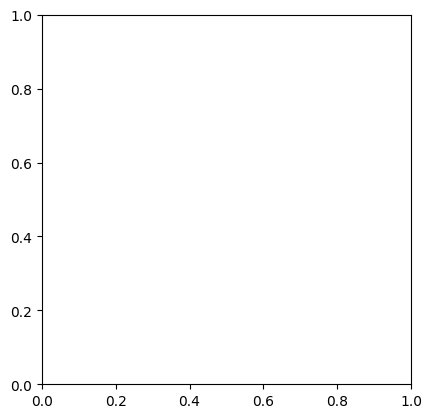

In [ ]:
plt.imshow(X[1])